In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import shap

df = pd.read_csv('../data/processed/cleaned_sales.csv', parse_dates=['InvoiceDate'])

# Define churn: No purchase in last 90 days
snapshot_date = df['InvoiceDate'].max()
last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase['days_since_last'] = (snapshot_date - last_purchase['InvoiceDate']).dt.days
last_purchase['churn'] = (last_purchase['days_since_last'] > 90).astype(int)

print(f"Churn rate: {last_purchase['churn'].mean():.2%}")

Churn rate: 50.69%


In [7]:
# Load RFM
rfm = pd.read_csv('../data/processed/customer_segments.csv')

# Additional features
features = df.groupby('Customer ID').agg({
    'Quantity': ['mean', 'std', 'sum'],
    'Price': ['mean', 'std'],
    'TotalPrice': ['mean', 'std', 'sum'],
    'InvoiceDate': lambda x: (x.max() - x.min()).days,  # Customer lifespan
    'StockCode': 'nunique'  # Unique products purchased
}).reset_index()

# Flatten column names
features.columns = ['Customer ID', 'avg_quantity', 'std_quantity', 'total_quantity',
                    'avg_price', 'std_price', 'avg_order_value', 'std_order_value',
                    'total_spent', 'customer_lifespan_days', 'unique_products']

# Merge with RFM and churn
features = features.merge(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Segment']], 
                          on='Customer ID')
features = features.merge(last_purchase[['Customer ID', 'churn']], on='Customer ID')

In [8]:
X = features.drop(['Customer ID', 'churn'], axis=1)
y = features['churn']

# Handle missing values
X = X.fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (4544, 14), Test shape: (1136, 14)


In [9]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),  # Handle imbalance
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00       576

    accuracy                           1.00      1136
   macro avg       1.00      1.00      1.00      1136
weighted avg       1.00      1.00      1.00      1136

AUC-ROC: 1.0000


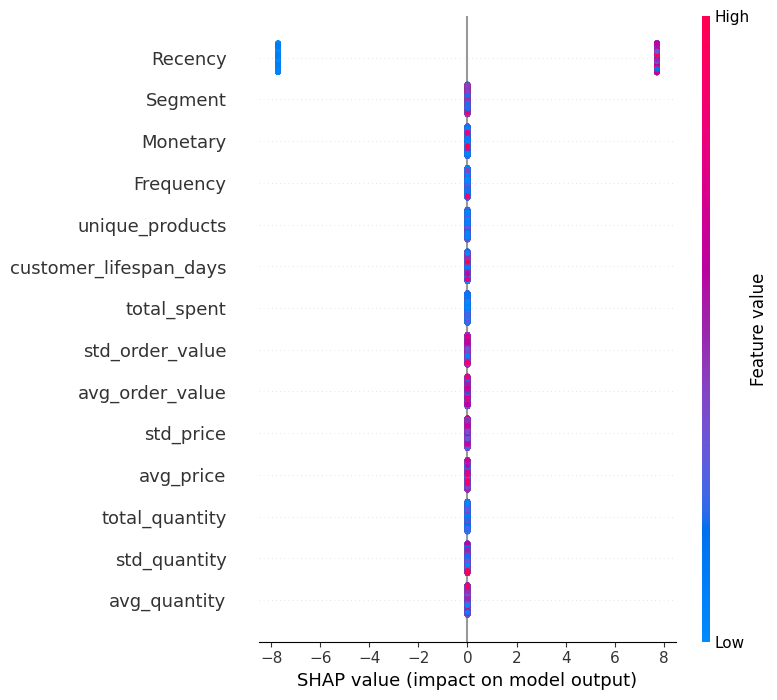

In [10]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png')
plt.show()


In [11]:
features['churn_probability'] = xgb_model.predict_proba(features.drop(['Customer ID', 'churn'], axis=1))[:, 1]
at_risk = features[features['churn_probability'] > 0.7].sort_values('churn_probability', ascending=False)

print(f"\nNumber of at-risk customers: {len(at_risk)}")
print(f"Total potential revenue at risk: £{at_risk['total_spent'].sum():,.2f}")

# Save
at_risk[['Customer ID', 'churn_probability', 'total_spent', 'Recency']].to_csv(
    '../data/processed/at_risk_customers.csv', index=False)

# Save model
import joblib
joblib.dump(xgb_model, '../src/models/churn_xgboost.pkl')


Number of at-risk customers: 2879
Total potential revenue at risk: £2,063,992.60


['../src/models/churn_xgboost.pkl']

In [ ]:
import joblib
joblib.dump(model, 'models/churn_model.pkl')